# 🏠 California Housing Price Regression — Decision Tree

**🇹🇷 Türkçe:**
Bu notebook, California mahallelerinin gelir, konut yaşı, oda sayısı, nüfus ve konum gibi özelliklerinden medyan ev fiyatını (`MedHouseVal`) tahmin eden bir Karar Ağacı Regresörü (`DecisionTreeRegressor`) kuruyor.

Model, `Pipeline` + `ColumnTransformer` içinde ölçekleme adımıyla birlikte tanımlanıyor ve `GridSearchCV` ile `criterion`, `max_depth`, `min_samples_leaf` parametreleri 5 katlı çapraz doğrulama üzerinden aranıyor.

**🇬🇧 English:**
This notebook builds a Decision Tree Regressor (`DecisionTreeRegressor`) that predicts the median house value (`MedHouseVal`) of California districts from features such as income, housing age, room counts, population, and location.

The model is defined inside a `Pipeline` + `ColumnTransformer` with a scaling step, and `GridSearchCV` searches over `criterion`, `max_depth`, and `min_samples_leaf` with 5-fold cross-validation.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme, görselleştirme ve modelleme için gerekli kütüphaneler tek hücrede toplanıyor.

**🇬🇧 English:**
The libraries needed for data handling, visualization, and modeling are collected in a single cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme ve İlk Bakış / Load the Dataset and First Look

**🇹🇷 Türkçe:**
California Housing veri seti yükleniyor: 20.640 satır, gelir (`MedInc`), konut yaşı (`HouseAge`), oda/yatak odası sayıları, nüfus, doluluk, konum (`Latitude`/`Longitude`) ve hedef değişken `MedHouseVal` (medyan ev fiyatı, yüz binlerce dolar cinsinden). `describe()`, eksik değer ve kopya kontrolleri veri setinin temiz olduğunu doğruluyor.

**🇬🇧 English:**
The California Housing dataset is loaded: 20,640 rows with income (`MedInc`), housing age (`HouseAge`), room/bedroom counts, population, occupancy, location (`Latitude`/`Longitude`), and the target `MedHouseVal` (median house value, in hundreds of thousands of dollars). `describe()` along with missing-value and duplicate checks confirm the dataset is clean.

In [2]:
df = pd.read_csv("../../Data/21-california_housing_regression.csv")

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 🔍 2. Görsel Keşifsel Veri Analizi / Visual EDA

**🇹🇷 Türkçe:**
Korelasyon ısı haritası, `MedInc` kolonundaki aykırı değerlere bakan bir kutu grafiği ve `MedInc` ile hedef arasındaki ilişkiyi gösteren bir dağılım grafiği çiziliyor. Karar ağaçları, doğrusal modellerin aksine aykırı değerlere ve özellik ölçeklerine karşı görece dayanıklıdır — yine de veriyi görsel olarak anlamak model seçimini ve yorumlamayı güçlendirir.

**🇬🇧 English:**
A correlation heatmap, a boxplot examining outliers in `MedInc`, and a scatterplot of `MedInc` against the target are plotted. Unlike linear models, decision trees are relatively robust to outliers and feature scale — but visually understanding the data still strengthens model choice and interpretation.

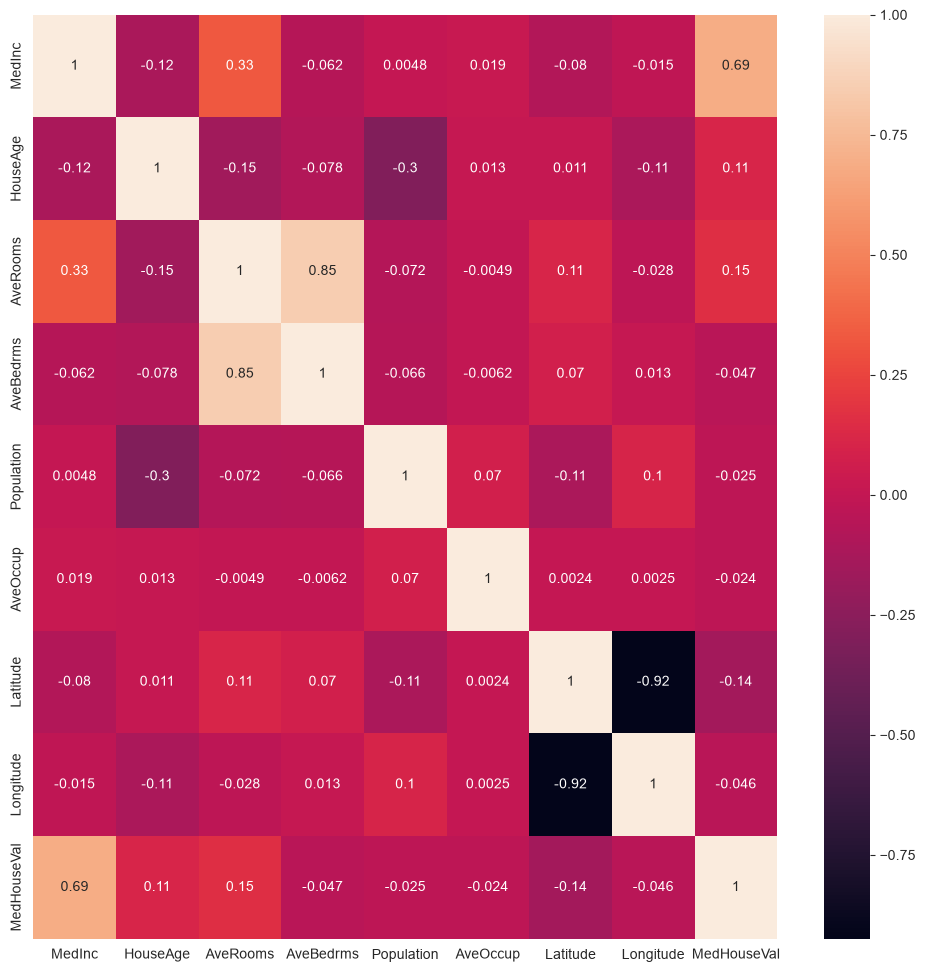

In [6]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True)
plt.show()

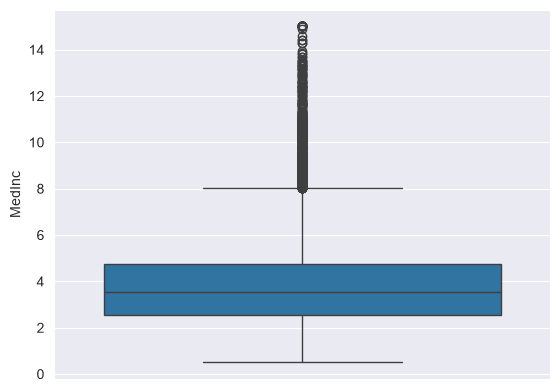

In [10]:
sns.boxplot(df["MedInc"])
plt.show()

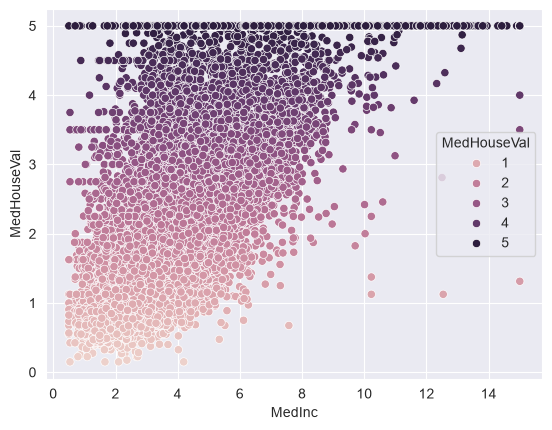

In [13]:
sns.scatterplot(x=df["MedInc"], y=df["MedHouseVal"], hue=df["MedHouseVal"])
plt.show()

## ✂️ 3. Özellik/Hedef Ayrımı ve Train-Test Bölme / Feature-Target Split and Train-Test Split

**🇹🇷 Türkçe:**
`X` (özellikler) ve `y` (hedef `MedHouseVal`) ayrılıp veri eğitim ve test setlerine bölünüyor. Bölme, ön işleme adımlarından önce yapılıyor ki ölçekleme istatistikleri yalnızca eğitim verisinden öğrenilsin.

**🇬🇧 English:**
`X` (features) and `y` (the target `MedHouseVal`) are separated, then the data is split into training and test sets. The split happens before any preprocessing so that scaling statistics are learned from the training data only.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

## 🔧 4. Pipeline ve Hiperparametre Optimizasyonu / Pipeline and Hyperparameter Tuning

**🇹🇷 Türkçe:**
Tüm sayısal özellikler `StandardScaler` ile ölçekleniyor ve bu adım `ColumnTransformer` + `Pipeline` içine yerleştiriliyor. Karar ağaçları ölçeklemeye ihtiyaç duymasa da, ölçekleme pipeline'ı gelecekte mesafe tabanlı bir modelle değiştirmeyi kolaylaştıran zararsız bir alışkanlıktır.

`GridSearchCV`, `criterion` (bölünme kalitesi ölçütü), `max_depth` (ağaç derinliği) ve `min_samples_leaf` (bir yaprakta bulunması gereken minimum örnek sayısı) parametrelerini 5 katlı çapraz doğrulama ile `r2` skoruna göre tarıyor. `min_samples_leaf`'in düşük değerleri (`1` gibi) aşırı öğrenmeye, yüksek değerleri ise yetersiz öğrenmeye yol açabilir.

**🇬🇧 English:**
All numerical features are scaled with `StandardScaler`, wrapped inside a `ColumnTransformer` + `Pipeline`. Decision trees don't strictly need scaling, but keeping it in the pipeline is a harmless habit that makes it easy to swap in a distance-based model later.

`GridSearchCV` searches over `criterion` (split-quality measure), `max_depth` (tree depth), and `min_samples_leaf` (minimum samples required at a leaf) with 5-fold cross-validation, scored by `r2`. Low values of `min_samples_leaf` (like `1`) can lead to overfitting, while high values can lead to underfitting.

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [69]:
numerical_features = X.columns.tolist()
params = {
    "criterion": ["squared_error", "absolute_error","poisson"],
    "splitter": ["best", "random"],
    "max_depth" : [5,6,7,8,9,10,15,None],
    "max_features" : ["sqrt", "log2", None]
}

In [77]:
numerical_features = X.columns.tolist()

scaled_pipeline = Pipeline([("scaler", StandardScaler())])
preprocessor = ColumnTransformer([("num", scaled_pipeline, numerical_features)])

model_pipeline = Pipeline([
    ("pre", preprocessor),
    ("model", DecisionTreeRegressor())
])

params = {
    "model__criterion": ["squared_error", "absolute_error"],
    "model__max_depth": [5, 6, 7, 8, 9, 10, 15, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
}

grid = GridSearchCV(estimator=model_pipeline, param_grid=params,
                    scoring="r2", cv=5, n_jobs=-1)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [5, 6, ...], 'model__min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

In [78]:
grid.best_params_

{'model__criterion': 'squared_error',
 'model__max_depth': None,
 'model__min_samples_leaf': 20}

## 📊 5. Model Değerlendirmesi / Model Evaluation

**🇹🇷 Türkçe:**
En iyi model test setinde `R²`, `MSE` ve `MAE` ile değerlendiriliyor. `R² ≈ 0.73` demek, modelin ev fiyatlarındaki varyansın yaklaşık %73'ünü açıklayabildiği anlamına gelir. En iyi parametrelerin `min_samples_leaf=20` çıkması dikkat çekici: yaprak başına yalnızca 1 örnek bırakan sınırsız bir ağaç (`max_depth=None`, `min_samples_leaf=1`), eğitim verisini ezberleyip test setinde daha kötü genelleyebilirdi; `min_samples_leaf=20` ağacın gürültüye karşı biraz daha genellenmiş, düzenlileştirilmiş kalmasını sağlıyor.

**🇬🇧 English:**
The best model is evaluated on the test set with `R²`, `MSE`, and `MAE`. `R² ≈ 0.73` means the model explains roughly 73% of the variance in house prices. It's worth noting that the best parameters settled on `min_samples_leaf=20`: an unconstrained tree with just 1 sample per leaf (`max_depth=None`, `min_samples_leaf=1`) could memorize the training data and generalize worse on the test set; `min_samples_leaf=20` keeps the tree somewhat regularized against noise.

In [79]:
y_pred = grid.predict(X_test)

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [81]:
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.7269715626938525
0.36317663209590334
0.4042032680979355


## ✅ 6. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- California Housing veri setinde bir `DecisionTreeRegressor`, `GridSearchCV` ile `criterion`, `max_depth`, `min_samples_leaf` üzerinde 5 katlı çapraz doğrulama ile ayarlandı.
- En iyi kombinasyon `criterion="squared_error"`, `max_depth=None`, `min_samples_leaf=20` oldu; bu, sınırsız derinliğe izin verirken yaprak başına minimum örnek sayısıyla aşırı öğrenmeyi frenliyor.
- Test setinde **R² ≈ 0.73**, MAE ≈ 0.40 (yüz binlerce dolar cinsinden) elde edildi.
- Ders: Karar ağaçlarında `max_depth=None` tek başına tehlikeli değildir — `min_samples_leaf` gibi tamamlayıcı bir düzenlileştirme parametresiyle birlikte arandığında, sınırsız derinlik ile aşırı öğrenme arasındaki dengeyi grid search bulabilir.

**🇬🇧 English:**
- A `DecisionTreeRegressor` on the California Housing dataset was tuned with `GridSearchCV` over `criterion`, `max_depth`, and `min_samples_leaf` using 5-fold cross-validation.
- The best combination was `criterion="squared_error"`, `max_depth=None`, `min_samples_leaf=20` — allowing unlimited depth while the minimum-samples-per-leaf constraint keeps overfitting in check.
- On the test set this reached **R² ≈ 0.73** and MAE ≈ 0.40 (in hundreds of thousands of dollars).
- Takeaway: `max_depth=None` alone isn't inherently dangerous for decision trees — when searched alongside a complementary regularization parameter like `min_samples_leaf`, grid search can find the balance between unlimited depth and overfitting.